<a href="https://colab.research.google.com/github/AryanSC123/AryanSC123/blob/main/Pneumonia_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/Dataset/Chest XRAY - Pneumonia Dataset/train"
test_dir = "/content/drive/MyDrive/Dataset/Chest XRAY - Pneumonia Dataset/test"

Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

# Only rescale for test/validation
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=64,
    class_mode='sparse',
    shuffle=True
)

# Load test data
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(160, 160),
    batch_size=64,
    class_mode='sparse',
    shuffle=False
)

Found 5216 images belonging to 3 classes.
Found 40 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load MobileNetV2 without top layer
base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base layers
base_model.trainable = False

# Add custom layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=64,
    class_mode='sparse',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=64,
    class_mode='sparse',
    subset='validation'
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop]
)

model.save("/content/pneumonia_model.keras")

Found 4173 images belonging to 3 classes.
Found 1043 images belonging to 3 classes.
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1434s 21s/step - accuracy: 0.6954 - loss: 0.7309 - val_accuracy: 0.7574 - val_loss: 0.5453
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 64s 970ms/step - accuracy: 0.7803 - loss: 0.5251 - val_accuracy: 0.7737 - val_loss: 0.5356
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 65s 985ms/step - accuracy: 0.7949 - loss: 0.4870 - val_accuracy: 0.7776 - val_loss: 0.5143
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 62s 938ms/step - accuracy: 0.8004 - loss: 0.4572 - val_accuracy: 0.7335 - val_loss: 0.5552
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8030 - loss: 0.4594 - val_accuracy: 0.7804 - val_loss: 0.5026
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8253 - loss: 0.4195 - val_accuracy: 0.7833 - val_loss: 0.4990
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 65s 985ms/step - accuracy: 0.8169 - loss: 0.4201 - val_accuracy: 0.7699 - val_loss: 0.5186
Epoch 8/30
66/66 ━━

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.2f}, Test Loss: {test_loss:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.9000 - loss: 0.5127
Test Accuracy: 0.90, Test Loss: 0.51


Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']


FileUpload(value={}, accept='image/*', description='Upload')

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: BACTERIAL (98.23%) স্বেচ্ছাসেবক)
Original Image:


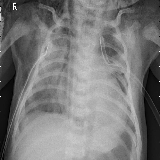

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


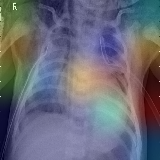

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction: BACTERIAL (98.67%) স্বেচ্ছাসেবক)
Original Image:


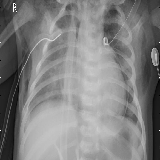

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


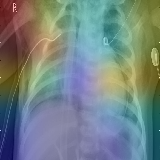

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: BACTERIAL (90.37%) স্বেচ্ছাসেবক)
Original Image:


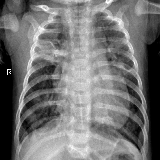

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


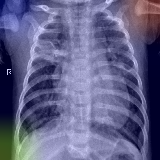

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediction: BACTERIAL (93.19%) স্বেচ্ছাসেবক)
Original Image:


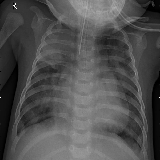

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


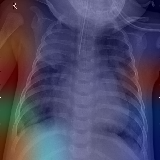

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Prediction: BACTERIAL (96.11%) স্বেচ্ছাসেবক)
Original Image:


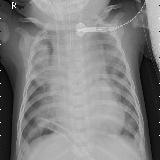

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


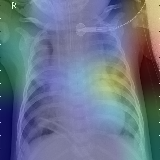

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: BACTERIAL (72.95%) স্বেচ্ছাসেবক)
Original Image:


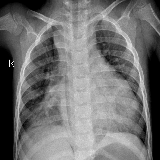

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


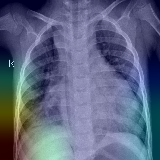

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: BACTERIAL (71.03%) স্বেচ্ছাসেবক)
Original Image:


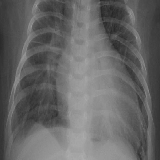

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


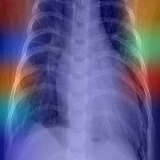

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: BACTERIAL (97.86%) স্বেচ্ছাসেবক)
Original Image:


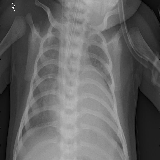

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


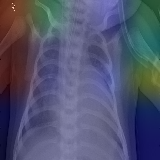

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: BACTERIAL (96.45%) স্বেচ্ছাসেবক)
Original Image:


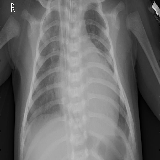

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


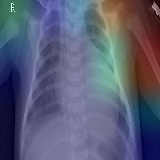

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: BACTERIAL (98.51%) স্বেচ্ছাসেবক)
Original Image:


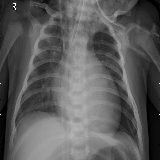

Grad-CAM:


/tmp/ipykernel_2635/1267678376.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


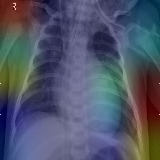

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.utils import load_img, img_to_array
from IPython.display import display
import ipywidgets as widgets

# Load trained model
model = tf.keras.models.load_model("/content/pneumonia_model.keras")

# Get class names from your generator
class_indices = train_data.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Classes:", class_names)

last_conv_layer_name = "Conv_1"  # correct for MobileNetV2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    # Get the MobileNetV2 base model (which is the first layer of the sequential model)
    base_model = model.get_layer("mobilenetv2_1.00_160")
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Create a sub-model that goes from the input of the base_model to the last convolutional layer's output
    # This explicitly defines the path for feature extraction
    feature_extractor = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:
        # Pass the input image through the feature extractor to get the conv_outputs
        conv_outputs = feature_extractor(img_array)

        # Explicitly watch conv_outputs to ensure gradients are tracked
        tape.watch(conv_outputs)

        # Now, pass the conv_outputs through the rest of the sequential model layers
        # starting from the layer immediately after the base_model.
        # model.layers[0] is base_model
        # model.layers[1] is GlobalAveragePooling2D
        # model.layers[2] is Dense(128)
        # model.layers[3] is Dropout
        # model.layers[4] is Dense(3)
        x = model.layers[1](conv_outputs)
        x = model.layers[2](x)
        x = model.layers[3](x)
        predictions = model.layers[4](x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    # Handle the case where gradients are None
    if grads is None:
        # This indicates a problem in the gradient computation path.
        # It's better to raise an error or return an empty heatmap than proceed with None.
        print("Warning: Gradients are None. Cannot compute Grad-CAM.")
        # Return an empty heatmap of appropriate size, assuming batch size 1
        return np.zeros(conv_outputs.shape[1:3])

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0] # Remove batch dimension
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
  img = load_img(img_path, target_size=(160,160))
  img = img_to_array(img)

  heatmap = np.uint8(255 * heatmap)

  jet = cm.get_cmap("jet")
  jet_colors = jet(np.arange(256))[:, :3]
  jet_heatmap = jet_colors[heatmap]

  jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
  jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
  jet_heatmap = img_to_array(jet_heatmap)

  superimposed_img = jet_heatmap * alpha + img
  superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

  display(superimposed_img)

def predict_and_visualize(img_path):
    img = load_img(img_path, target_size=(160,160))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    preds = model.predict(img_array)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class] * 100

    print(f"Prediction: {class_names[pred_class]} ({confidence:.2f}%) স্বেচ্ছাসেবক)")

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_class)

    print("Original Image:")
    display(img)

    print("Grad-CAM:")
    display_gradcam(img_path, heatmap)

upload = widgets.FileUpload(accept='image/*', multiple=False)

def on_upload_change(change):
    if upload.value:
        file_name = list(upload.value.keys())[0]
        content = upload.value[file_name]['content']

        path = "/tmp/test.png"
        with open(path, "wb") as f:
            f.write(content)

        predict_and_visualize(path)

upload.observe(on_upload_change, names='value')

display(upload)